In [1]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [2]:
query = """

select r20_21.*, stations.*

from (

select *
from `bigquery-public-data.noaa_gsod.gsod2020`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2021`

) as r20_21
join `bigquery-public-data.noaa_gsod.stations` as stations on r20_21.stn = stations.usaf and r20_21.wban = stations.wban
"""

query_job = client.query(query)
query_result = query_job.result()
# weather and stations
dfwas = query_result.to_dataframe()

Część 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = dfwas.copy()
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["month"] = data["date"].dt.month
data["mxpsd"] = pd.to_numeric(data["mxpsd"], errors="coerce")

missing_codes = {
    "temp": 9999.9,
    "max": 9999.9,
    "min": 9999.9,
    "dewp": 9999.9,
    "slp": 9999.9,
    "stp": 9999.9,
    "visib": 999.9,
    "wdsp": 999.9,
    "mxpsd": 999.9,
    "gust": 999.9,
    "prcp": 99.99
}

for col, code in missing_codes.items():
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].replace(code, np.nan)

sns.set(style="whitegrid")

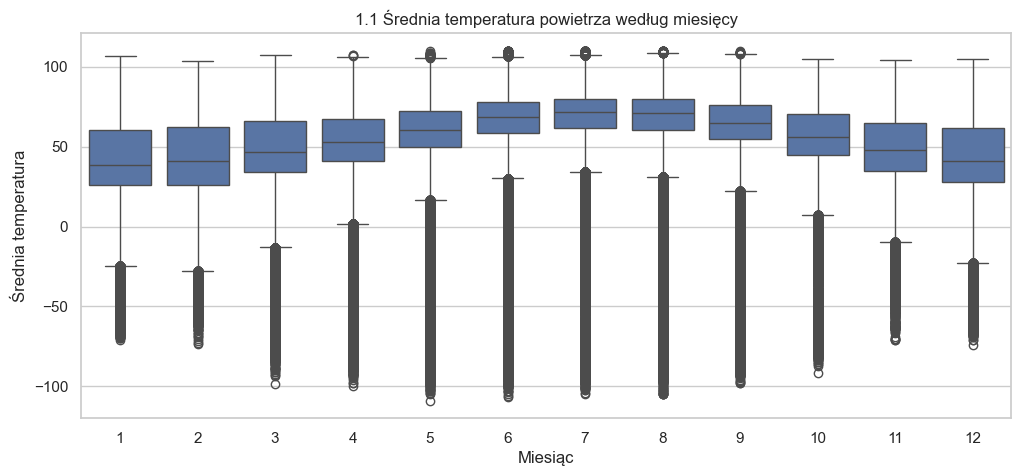

In [12]:
#1.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="temp", data=data)
plt.title("1.1 Średnia temperatura powietrza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia temperatura")
plt.show()

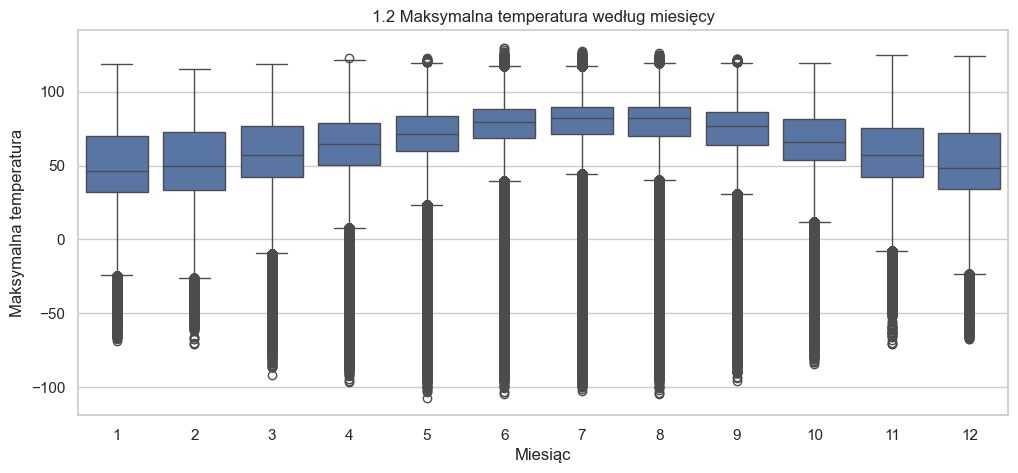

In [13]:
#1.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="max", data=data)
plt.title("1.2 Maksymalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Maksymalna temperatura")
plt.show()

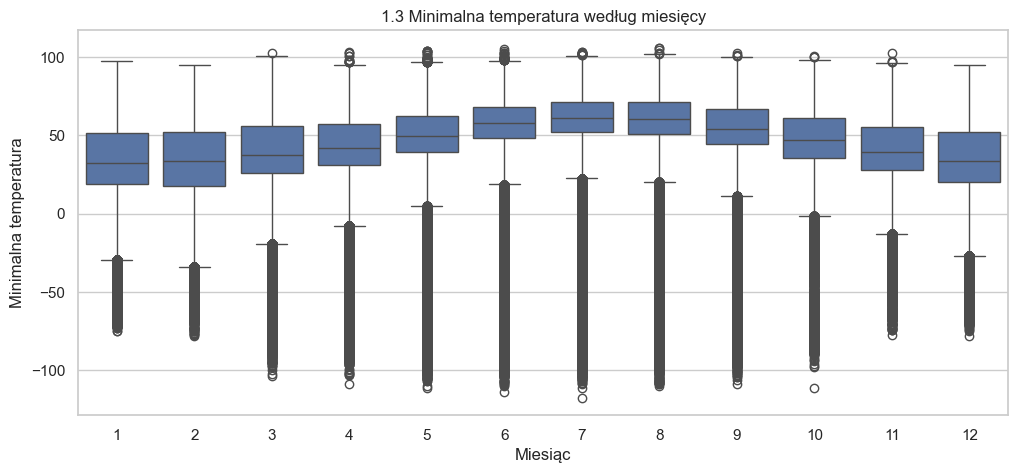

In [14]:
#1.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="min", data=data)
plt.title("1.3 Minimalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Minimalna temperatura")
plt.show()

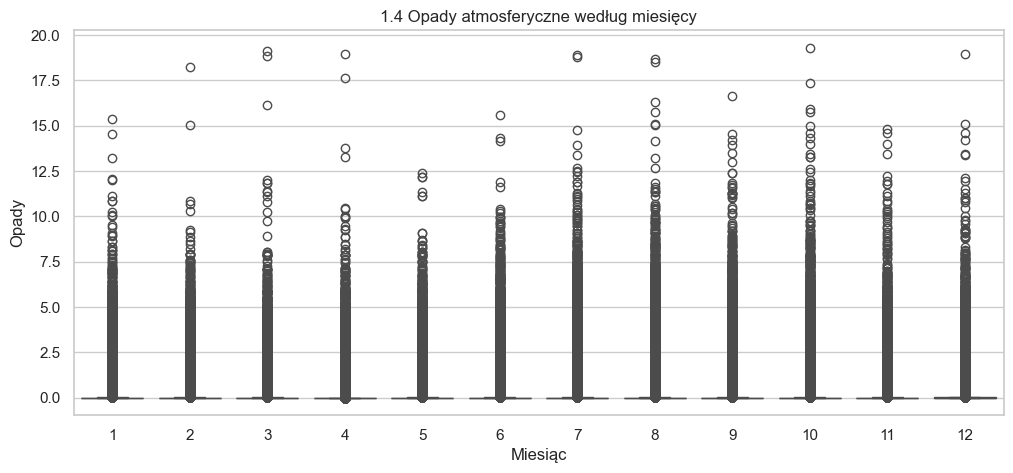

In [15]:
#1.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="prcp", data=data)
plt.title("1.4 Opady atmosferyczne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Opady")
plt.show()

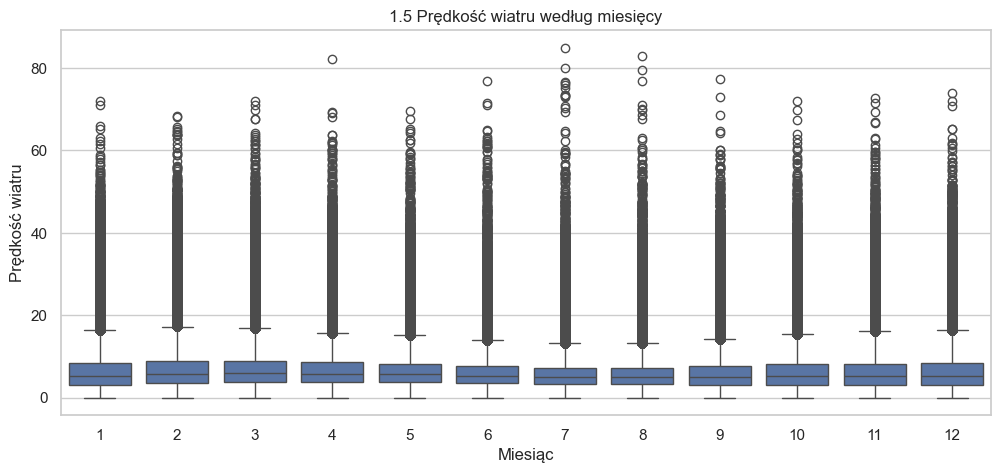

In [16]:
#1.5
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="wdsp", data=data)
plt.title("1.5 Prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Prędkość wiatru")
plt.show()

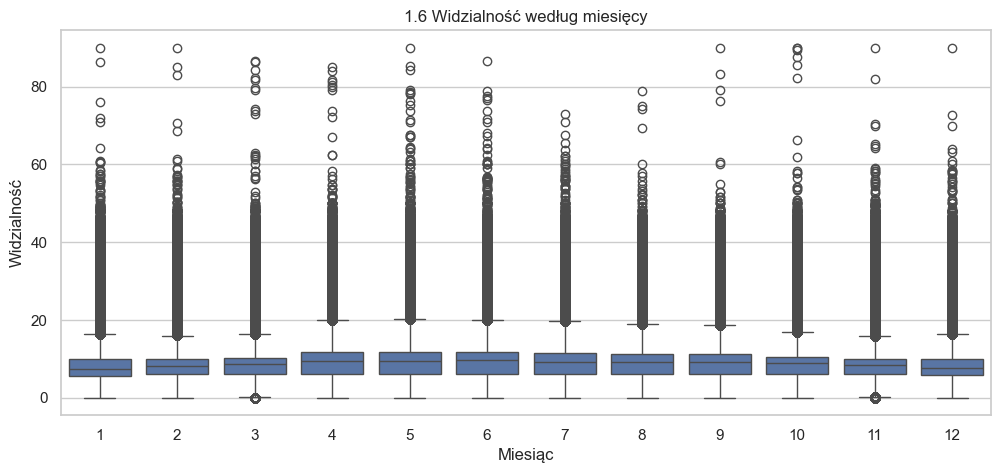

In [17]:
#1.6
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="visib", data=data)
plt.title("1.6 Widzialność według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Widzialność")
plt.show()

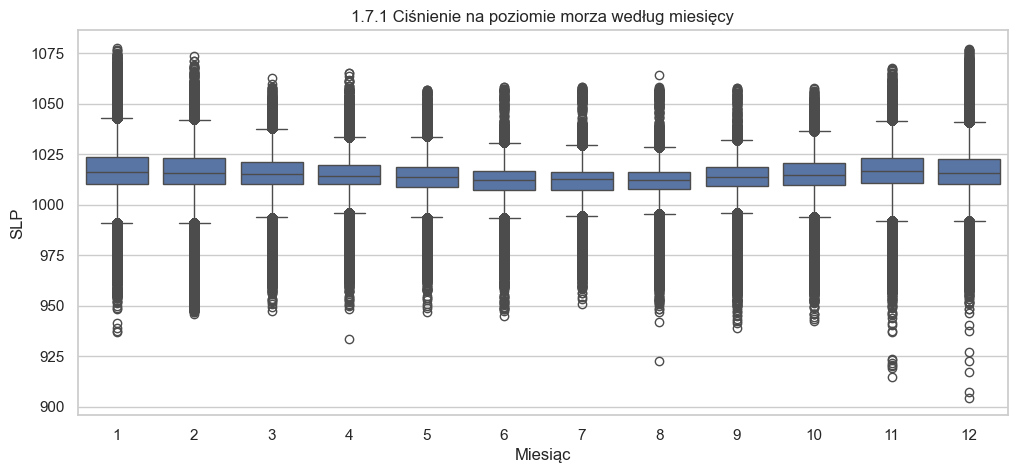

In [18]:
#1.7.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="slp", data=data)
plt.title("1.7.1 Ciśnienie na poziomie morza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("SLP")
plt.show()

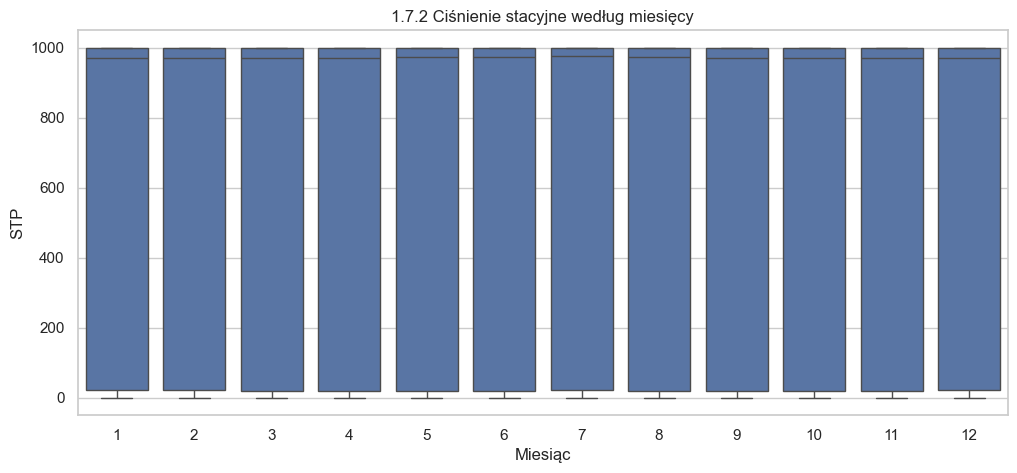

In [19]:
#1.7.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="stp", data=data)
plt.title("1.7.2 Ciśnienie stacyjne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("STP")
plt.show()

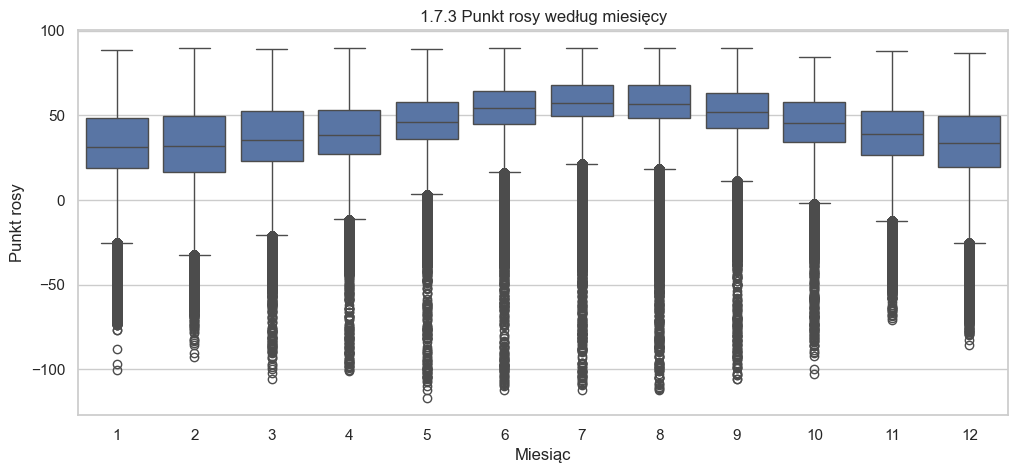

In [20]:
#1.7.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="dewp", data=data)
plt.title("1.7.3 Punkt rosy według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Punkt rosy")
plt.show()

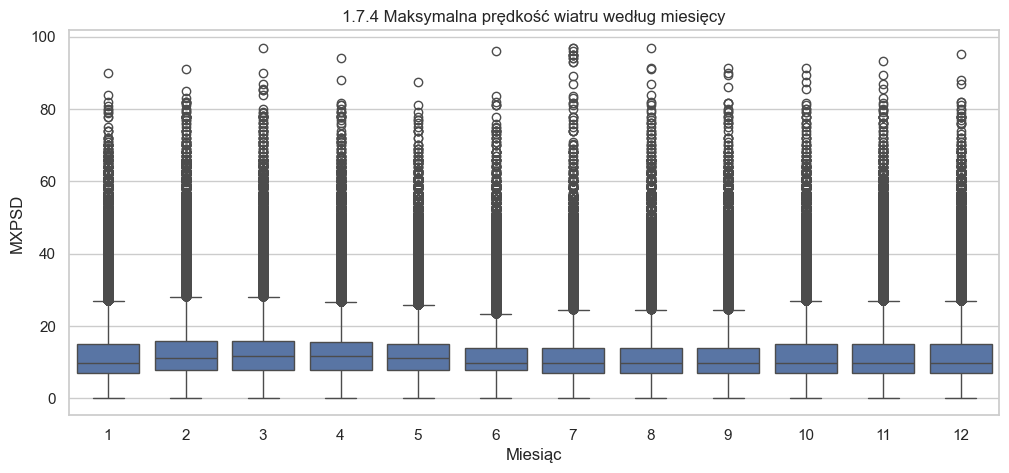

In [28]:
#1.7.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="mxpsd", data=data)
plt.title("1.7.4 Maksymalna prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("MXPSD")
plt.show()

Część 2

Część 3

In [29]:
data = dfwas.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")

print(data.dtypes)

stn                             object
wban                            object
date                    datetime64[ns]
year                            object
mo                              object
da                              object
temp                           float64
count_temp                       Int64
dewp                           float64
count_dewp                       Int64
slp                            float64
count_slp                        Int64
stp                            float64
count_stp                        Int64
visib                          float64
count_visib                      Int64
wdsp                            object
count_wdsp                      object
mxpsd                           object
gust                           float64
max                            float64
flag_max                        object
min                            float64
flag_min                        object
prcp                           float64
flag_prcp                

In [30]:
#3.1
missing_summary = pd.DataFrame({
    "liczba_brakow": data.isna().sum(),
    "procent_brakow": round(data.isna().sum() / len(data) * 100, 2)
})

missing_summary = missing_summary.sort_values("liczba_brakow", ascending=False)
missing_summary

,liczba_brakow,procent_brakow
state,6207545,76.45
flag_min,4913008,60.51
flag_max,4786959,58.96
call,3926108,48.35
flag_prcp,604290,7.44
country,183,0.00
elev,58,0.00
lon,2,0.00
lat,2,0.00
stn,0,0.00


In [31]:
#3.2
weather_cols = ["temp", "max", "min", "prcp", "wdsp", "visib", "slp", "stp", "dewp", "mxpsd"]

for col in weather_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

if "temp" in data.columns:
    data["temp"] = data["temp"].replace(9999.9, np.nan)
if "max" in data.columns:
    data["max"] = data["max"].replace(9999.9, np.nan)
if "min" in data.columns:
    data["min"] = data["min"].replace(9999.9, np.nan)
if "dewp" in data.columns:
    data["dewp"] = data["dewp"].replace(9999.9, np.nan)
if "slp" in data.columns:
    data["slp"] = data["slp"].replace(9999.9, np.nan)
if "stp" in data.columns:
    data["stp"] = data["stp"].replace(9999.9, np.nan)

if "visib" in data.columns:
    data["visib"] = data["visib"].replace(999.9, np.nan)
if "wdsp" in data.columns:
    data["wdsp"] = data["wdsp"].replace(999.9, np.nan)
if "mxpsd" in data.columns:
    data["mxpsd"] = data["mxpsd"].replace(999.9, np.nan)

if "prcp" in data.columns:
    data["prcp"] = data["prcp"].replace(99.99, np.nan)